In [1]:
from utils import*

# x2ns

## Create dict 'loo' with all Leave One Out results

In [2]:
# folder_path = '../data/fold_results/LOO/'
# files_pattern = '*.pkl.gz'
# files = glob.glob(folder_path + files_pattern)

# loo = {}

# # Iterate over each file
# for file_path in files:
#     # Extract the fold number from the file name
#     fold_number = file_path.split('_')[-1].split('.')[0]
    
#     # Read the pickle file and populate loo dictionary
#     loo[fold_number] = pd.read_pickle(file_path)

## Collect network sizes in cpds_subiter[1] from each dict

In [3]:
# # create xgroup2networkSize dict

# x2ns = {}
# for xgroup in loo:
#     if xgroup not in ['spontaneous', 'fold-independent']:  # ignore non-fold leave-one-out reults
#         x2ns[xgroup] = len(loo[xgroup].cpds_subiter[1])

# # save dict as csv
# dict2csv(x2ns, '../data/assets/xgroup2/xgroup2networkSize.csv')

# x2rulesNum, x2rnNum from rn2rules

In [4]:
# preATP 1000 runs

df_folds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/folds_folditer_preATP.csv', index_col=0)
df_cpds_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/cpds_folditer_preATP.csv', index_col=0)
df_rns_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rns_folditer_preATP.csv', index_col=0)
df_rules_folditer = pd.read_csv('../data/1000runs_csvs/1000runs_csvs_preATP/rules_folditer_preATP.csv', index_col=0)

rns_scope = list(df_rns_folditer.index)
cpds_scope = list(df_cpds_folditer.index)
rn2rules_scope = {k:v for k,v in rn2rules.items() if k in rns_scope}
len(rn2rules_scope)

5730

In [5]:
def numRulesWith(xgroup):
    numRules = 0
    for reaction, rules in rn2rules_scope.items():
        for rule in rules:
            if xgroup in rule:
                numRules += 1
    return numRules

In [6]:
x2rulesNum = {}
for xgroup in x2ns.keys():
    x2rulesNum[xgroup] = numRulesWith(xgroup)

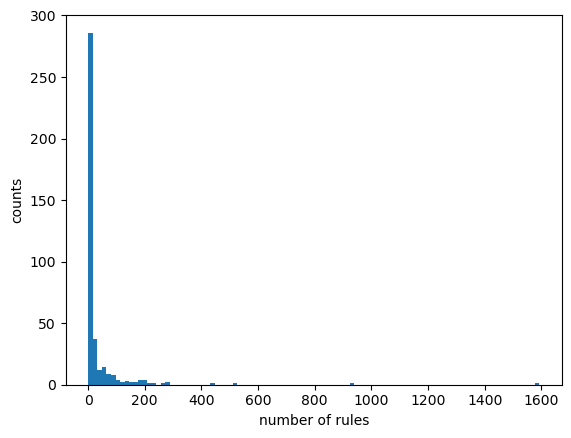

In [7]:
histogram(x2rulesNum, bins=100, x_axis = 'number of rules')

In [8]:
# dict2csv(x2rulesNum, '../data/assets/xgroup2/xgroup2rulesNum.csv')

In [9]:
def numRnWith(xgroup):
    rnWithX = []
    for reaction, rules in rn2rules_scope.items():
        for rule in rules:
            if xgroup in rule:
                rnWithX.append(reaction)
                break
    return len(set(rnWithX))

x2rnNum = {}
for xgroup in x2ns.keys():
    x2rnNum[xgroup] = numRnWith(xgroup)

# scatterplot: network size vs. #rules or #rns

network size vs. #rules: corr = -0.6074242102067334, p_value = 2.69E-41


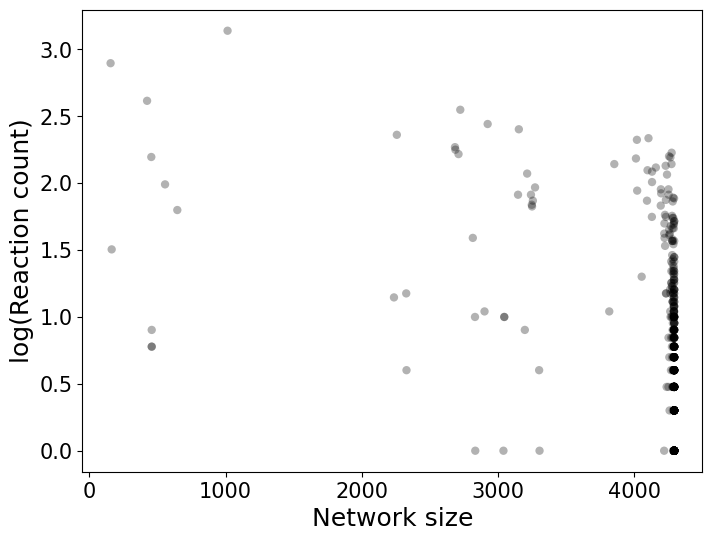

In [10]:
corr, p = spearman(x2ns, x2rnNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

valid_keys, data1, data2 = todata(x2ns, x2rnNum)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color='k', alpha = 0.3, label='Data Points', zorder=2)

# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
# ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('Network size', fontsize=18)
ax.set_ylabel('log(Reaction count)', fontsize=18)
plt.tick_params(labelsize=15)

# plt.savefig('scatter_networkSize2numRulesLog.svg', dpi=300, bbox_inches = 'tight')
plt.show()

### color by class

network size vs. #rules: corr = -0.6074242102067334, p_value = 2.69E-41


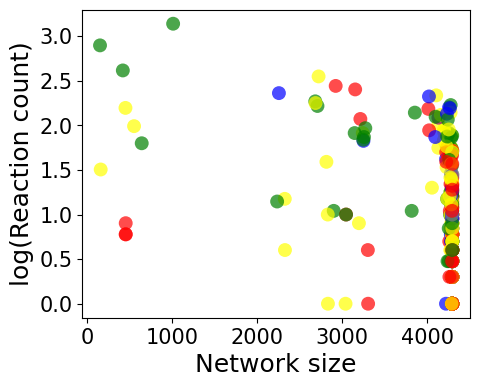

In [11]:
class2color = {'beta':'blue', 'alpha':'red', 'a+b':'yellow', 'a/b':'green', 'mixed':'purple', 'other':'grey'}

corr, p = spearman(x2ns, x2rnNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

valid_keys, data1, data2 = todata(x2ns, x2rnNum)
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

colors = [class2color[x2class[k]] for k in valid_keys]
plt.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color=colors, alpha = 0.7, label='Data Points', zorder=2, s=100)

# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
# ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('Network size', fontsize=18)
ax.set_ylabel('log(Reaction count)', fontsize=18)
plt.tick_params(labelsize=15)

# plt.savefig('scatter_networkSize2numRulesLog.svg', dpi=300, bbox_inches = 'tight')
plt.show()

In [39]:
# bokeh plot

valid_keys, data1, data2 = todata(x2ns, x2rnNum)
labels = [x2name.get(k, k) for k in valid_keys]

# Convert data to ColumnDataSource for interactivity
source = ColumnDataSource(data={
    'x':data1,
    'y':np.log10(data2),
    'label': labels}
)

# Create figure
p = figure(
    x_axis_label='Network size',
    y_axis_label='log10(Reaction count)',
    width=800,
    height=600
)

# Scatter plot
p.scatter('x', 'y', source=source, size=8, color='black', alpha=0.3)

# Add hover tool
hover = HoverTool()
hover.tooltips = [("fold", "@label")]
p.add_tools(hover)

# Show the plot
show(p)

# divide xgroups based on two 'network size' thresholds: 1500 and 3600

In [13]:
# network size < 1500 => first10

xgroup2sub1500 = {}
xgroup2sup1500 = {}
for xgroup in x2ns:
    if x2ns[xgroup] < 1500:
        xgroup2sub1500[xgroup] = x2ns[xgroup]
    else:
        xgroup2sup1500[xgroup] = x2ns[xgroup]

In [14]:
# network size < 3600 => group1
# network size >= 3600 => group2

groupOne2ns = {}
groupTwo2ns = {}
for xgroup in x2ns:
    if x2ns[xgroup] < 3600:
        groupOne2ns[xgroup] = x2ns[xgroup]
    else:
        groupTwo2ns[xgroup] = x2ns[xgroup]

In [15]:
first10 = list(xgroup2sub1500.keys())
group1 = list(groupOne2ns.keys())
group2 = list(groupTwo2ns.keys())

# The first division is CoA; second division is Oxygen

### first10 vs. others

In [16]:
# cpds = list(loo['2002'].cpds_folditer.keys())
cpds = cpds_scope

In [17]:
# divider_cpds_first10 = []  # list of cpds that don't exist in any first10 LOO networks, but always exist others
# for cpd in cpds:
#     divide = [True, True]
#     for x in first10:
#         if loo[x].cpds_subiter[1].get(cpd, 'N/A') != 'N/A':  # check if absent
#             divide[0] = False
#             break
#     for x in (set(group2) | set(group1)) - set(first10):
#         if loo[x].cpds_subiter[1].get(cpd, 'N/A') == 'N/A':  # check if present
#             divide[1] = False
#             break

#     if False not in divide:
#         print(f"{cpd} {cpd2name[cpd]} divides first10 vs. others")
#         divider_cpds_first10.append(cpd)

In [18]:
# len(divider_cpds_first10)

In [19]:
# 'C00010' in divider_cpds_first10  # CoA

In [20]:
# for c in divider_cpds_first10:
#     if c.startswith('Z'):
#         print(c, cpd2name[c])

In [21]:
# for cpd in divider_cpds_first10:
#     if int(cpd[-5:]) < 100:
        # print(cpd, cpd2name[cpd])

In [22]:
# not ATP or NDPH?

In [23]:
# cpd = 'C00002'
# print(cpd2name[cpd])
# print('--------------')
# for x in first10:
#     print(f"X{x}: {loo[x].cpds_subiter[1].get(cpd, 'N/A')}")
    
# # you can get ATP without Rossmann, HUP, or alpha/beta-Hammerhead/Barrel-sandwich hybrid?

In [24]:
# cpd = 'C00004'
# print(cpd2name[cpd])
# print('--------------')
# for x in first10:
#     print(f"X{x}: {loo[x].cpds_subiter[1].get(cpd, 'N/A')}")
    
# # you can get NADH without Rossmann?

### group1 vs. group2

In [25]:
# divider_cpds_g1g2 = []  # list of cpds that don't exist in any group1 LOO networks, but always exist in group2 LOO
# for cpd in cpds:
#     divide = [True, True]
#     for x in group1:
#         if loo[x].cpds_subiter[1].get(cpd, 'N/A') != 'N/A':  # check if absent
#             divide[0] = False
#             break
#     for x in group2:
#         if loo[x].cpds_subiter[1].get(cpd, 'N/A') == 'N/A':  # check if present
#             divide[1] = False
#             break

#     if False not in divide:
#         print(f"{cpd} {cpd2name[cpd]} divides group1 vs. group2")
#         divider_cpds_g1g2.append(cpd)

In [26]:
# len(divider_cpds_g1g2)

In [27]:
# 'C00007' in divider_cpds_g1g2

In [28]:
# 'C00027' in divider_cpds_g1g2

# scatterplot: network size vs. #rules (with colors)

In [29]:
group1minus10ns = {}
for x, ns in groupOne2ns.items():
    if x not in first10:
        group1minus10ns[x] = ns

network size vs. #rules: corr = -0.6074242102067334, p_value = 2.69E-41


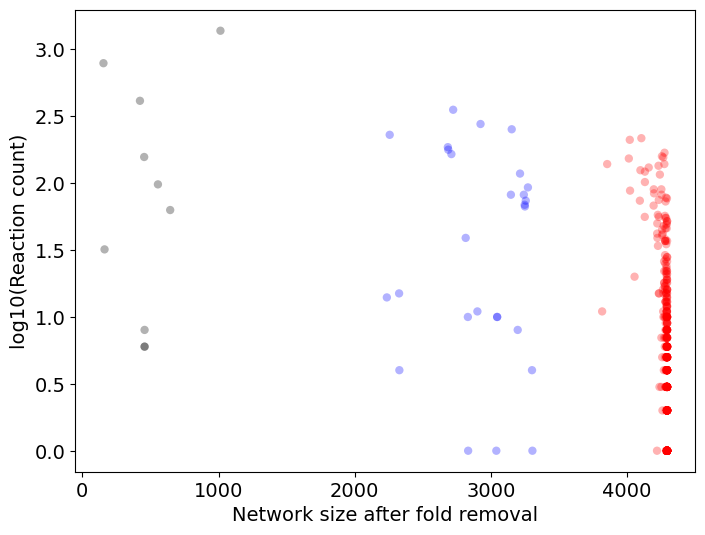

In [30]:
keys, data1, data2 = todata(group1minus10ns, x2rnNum)
keys, data3, data4 = todata(groupTwo2ns, x2rnNum)
keys, data5, data6 = todata(xgroup2sub1500, x2rnNum)

corr, p = spearman(x2ns, x2rnNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color='b', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data3, np.log10(data4), marker='o', edgecolor='none', color='r', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data5, np.log10(data6), marker='o', edgecolor='none', color='black', alpha = 0.3, label='Data Points', zorder=2)

# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
# ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('Network size after fold removal', fontsize=14)
ax.set_ylabel('log10(Reaction count)', fontsize=14)
plt.tick_params(labelsize=14)

# plt.savefig('scatter_networkSize2numRulesLog.svg', dpi=300, bbox_inches = 'tight')
plt.show()

In [31]:
x2name['2484'], x2name['2006']

('Ribonuclease H-like', 'HAD domain-like')

In [32]:
x2ns['2006'], np.log10(x2rnNum['2006'])

(4275, 2.2278867046136734)

In [33]:
x2ns['2484'], np.log10(x2rnNum['2484'])

(4131, 2.0863598306747484)

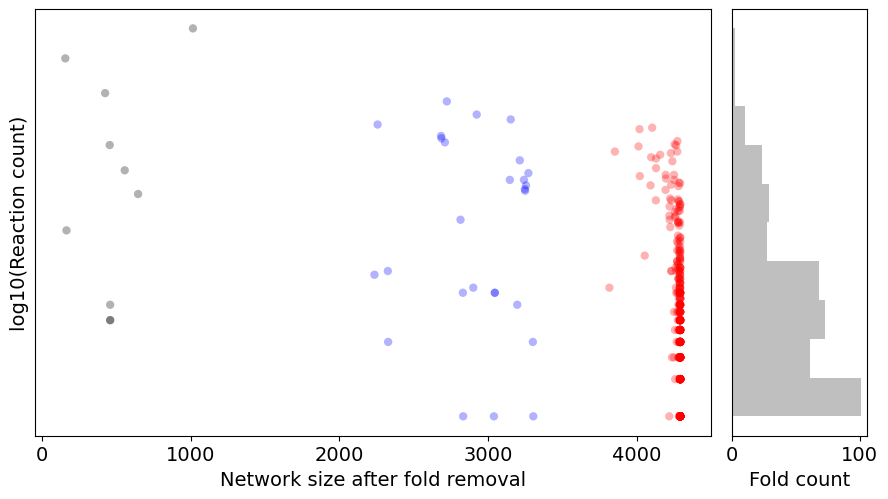

In [34]:
# add histogram
   
# Create a grid layout for scatter plot and histogram
fig = plt.figure(figsize=(9, 5.1))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 0.4])  # 1 row, 2 columns, [first col, second col]

# Scatter plot
ax_scatter = fig.add_subplot(gs[0])
ax_scatter.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color='b', alpha = 0.3, label='Data Points')
ax_scatter.scatter(data3, np.log10(data4), marker='o', edgecolor='none', color='r', alpha = 0.3, label='Data Points')
ax_scatter.scatter(data5, np.log10(data6), marker='o', edgecolor='none', color='black', alpha = 0.3, label='Data Points')   
ax_scatter.set_xlabel('Network size after fold removal', fontsize=14)
ax_scatter.set_ylabel('log10(Reaction count)', fontsize=14)
ax_scatter.yaxis.set_ticks_position('left')  # Force y-axis ticks on the scatter plot
ax_scatter.tick_params(axis='y', which='both', direction='in')  # Ensure ticks are inward

# Histogram
ax_hist = fig.add_subplot(gs[1], sharey=ax_scatter)
ax_hist.hist(np.log10(data2+data4+data6), bins=10, orientation='horizontal', color='gray', alpha=0.5, edgecolor=None)
ax_hist.tick_params(axis='y', left=False)  # Suppress y-ticks on the histogram
ax_hist.set_yticks([])  # Hide y-ticks for the histogram
ax_hist.set_ylabel("")  # No y-label for the histogram

# ax_hist.set_yscale('log')  # Apply log scale to the histogram x-axis
ax_hist.set_xlabel("Fold count", fontsize=14)  # Label for the histogram x-axis
# ax_hist.set_xticks([0, 10, 20, 30])

ax_scatter.tick_params(labelsize=14)
ax_hist.tick_params(labelsize=14)

# Layout adjustment
plt.tight_layout()

# plt.savefig('scatter_networkSize2numRulesLog_histo.svg', dpi=300, bbox_inches = 'tight')

plt.show()

# Boxplot: Phyletic Disribution Scores of Group1 vs. Group2

/var/folders/y2/h8jnq3ld4ng6lrxsflrh300c0000gp/T/ipykernel_9272/2741607856.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Group I', 'Group II'], fontsize=14)


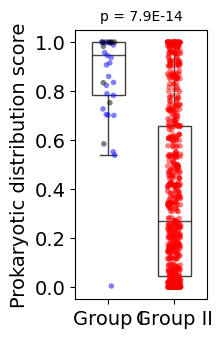

In [35]:
keys, data1, data2 = todata(x2ds, groupOne2ns)
keys, data3, data4 = todata(x2ds, groupTwo2ns)
keys, data5, data6 = todata(x2ds, xgroup2sub1500)

group1ds = np.array(data1)
group2ds = np.array(data3)
first10ds = np.array(data5)
group1minus10ds = np.array(list(set(data1) - set(data5)))

fig, ax = plt.subplots(figsize=(1.7, 3.5))

# Use seaborn boxplot
boxplot = sns.boxplot(data=[group1ds, group2ds], width=0.5, ax=ax, medianprops=dict(color="black", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0))

# data points
colors = ['blue', 'red']
sns.stripplot(data=[group1minus10ds, group2ds], palette=colors, size=4, jitter=True, ax=ax, alpha=0.5)
colors = ['black', 'red']
sns.stripplot(data=[first10ds, group2ds], palette=colors, size=4, jitter=True, ax=ax, alpha=0.5)

###
# U-test
statistic, p_value = mannwhitneyu(group1ds, group2ds)
p_value = '%.1E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')
###

plt.tick_params(labelsize=10)
plt.ylabel('Prokaryotic distribution score', fontsize=14)
ax.set_xticklabels(['Group I', 'Group II'], fontsize=14)

plt.tick_params(labelsize=14)

# plt.savefig('boxplot_ds_g1g2_first10.svg', dpi=300, bbox_inches = 'tight')
plt.show()

# Color based on redox ETU

In [36]:
x_FAD = {'1001', '146', '179', '187', '207', '217', '244', '262', '278', '296', '313', '3249', '3281', '3294', '3321', '3322', '3323', '3579', '3740', '378', '3892', '4019', '4033', '4052', '4294', '604', '6058', '6094', '629', '633', '66', '7', '7514', '7564', '7586', '842', '875', '881', '914', '920'}
x_NAD_no_Z32 = {'129', '146', '147', '148', '159', '179', '187', '213', '217', '221', '222', '236', '237', '239', '244', '2486', '262', '266', '270', '276', '3115', '313', '3249', '3294', '3321', '3322', '3323', '3579', '3654', '3687', '3692', '3697', '3699', '378', '3892', '4004', '4011', '4029', '4033', '4049', '4052', '4294', '4335', '503', '5100', '581', '604', '6058', '6094', '6096', '6166', '640', '66', '7', '7501', '7514', '7522', '7524', '7531', '7556', '7584', '7586', '842', '920'}

In [37]:
x_FAD_ns = {x:x2ns[x] for x in x_FAD}
x_NAD_ns = {x:x2ns[x] for x in x_NAD_no_Z32}

others_ns = {}
for x, ns in x2ns.items():
    if x not in x_NAD_ns and x not in x_FAD_ns:
        others_ns[x] = ns

print(len(x_FAD_ns), len(x_NAD_ns), len(others_ns))

40 64 319


network size vs. #rules: corr = -0.6006777627490734, p_value = 3.40E-40


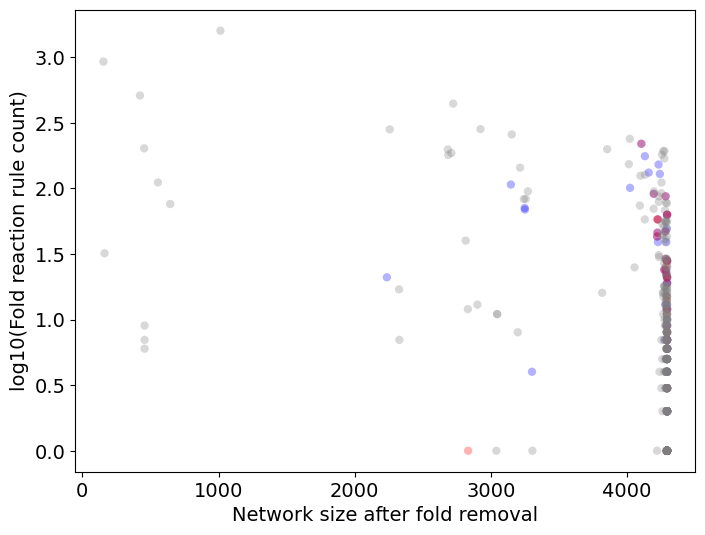

In [38]:
keys, data1, data2 = todata(x_NAD_ns, x2rulesNum)
keys, data3, data4 = todata(x_FAD_ns, x2rulesNum)
keys, data5, data6 = todata(others_ns, x2rulesNum)

corr, p = spearman(x2ns, x2rulesNum)
print(f'network size vs. #rules: corr = {corr}, p_value = {p}')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

plt.scatter(data1, np.log10(data2), marker='o', edgecolor='none', color='b', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data3, np.log10(data4), marker='o', edgecolor='none', color='r', alpha = 0.3, label='Data Points', zorder=2)
plt.scatter(data5, np.log10(data6), marker='o', edgecolor='none', color='gray', alpha = 0.3, label='Data Points', zorder=2)

# ax.axvspan(0, 3600, facecolor='yellow', alpha=0.2)
# ax.axvspan(3600, 4400, facecolor='green', alpha=0.2)
ax.set_xlabel('Network size after fold removal', fontsize=14)
ax.set_ylabel('log10(Fold reaction rule count)', fontsize=14)
plt.tick_params(labelsize=14)

# plt.savefig('scatter_networkSize2numRulesLog_redox.svg', dpi=300, bbox_inches = 'tight')
plt.show()